In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
import pandas as pd

df = pd.read_csv("bank-full.csv", sep=";")
df.shape

(45211, 17)

In [3]:
df.shape

(45211, 17)

In [4]:
df.duplicated().sum()

np.int64(0)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        45211 non-null  int64
 1   job        45211 non-null  str  
 2   marital    45211 non-null  str  
 3   education  45211 non-null  str  
 4   default    45211 non-null  str  
 5   balance    45211 non-null  int64
 6   housing    45211 non-null  str  
 7   loan       45211 non-null  str  
 8   contact    45211 non-null  str  
 9   day        45211 non-null  int64
 10  month      45211 non-null  str  
 11  duration   45211 non-null  int64
 12  campaign   45211 non-null  int64
 13  pdays      45211 non-null  int64
 14  previous   45211 non-null  int64
 15  poutcome   45211 non-null  str  
 16  y          45211 non-null  str  
dtypes: int64(7), str(10)
memory usage: 8.1 MB


In [6]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [7]:
df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

In [8]:
df.columns.tolist()

['age',
 'job',
 'marital',
 'education',
 'default',
 'balance',
 'housing',
 'loan',
 'contact',
 'day',
 'month',
 'duration',
 'campaign',
 'pdays',
 'previous',
 'poutcome',
 'y']

In [9]:
df["y"].value_counts()

y
no     39922
yes     5289
Name: count, dtype: int64

In [10]:
df["y"].value_counts(normalize=True)

y
no     0.883015
yes    0.116985
Name: proportion, dtype: float64

In [11]:
categorical_cols = df.select_dtypes(include="object").columns.tolist()
categorical_cols

/var/folders/_s/l9md4_2x5rj1z5hmcz54bvnr0000gn/T/ipykernel_3083/3728129623.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include="object").columns.tolist()


['job',
 'marital',
 'education',
 'default',
 'housing',
 'loan',
 'contact',
 'month',
 'poutcome',
 'y']

In [12]:
for col in categorical_cols:
    print(col)
    print(df[col].unique())
    print()

job
<ArrowStringArray>
[   'management',    'technician',  'entrepreneur',   'blue-collar',
       'unknown',       'retired',        'admin.',      'services',
 'self-employed',    'unemployed',     'housemaid',       'student']
Length: 12, dtype: str

marital
<ArrowStringArray>
['married', 'single', 'divorced']
Length: 3, dtype: str

education
<ArrowStringArray>
['tertiary', 'secondary', 'unknown', 'primary']
Length: 4, dtype: str

default
<ArrowStringArray>
['no', 'yes']
Length: 2, dtype: str

housing
<ArrowStringArray>
['yes', 'no']
Length: 2, dtype: str

loan
<ArrowStringArray>
['no', 'yes']
Length: 2, dtype: str

contact
<ArrowStringArray>
['unknown', 'cellular', 'telephone']
Length: 3, dtype: str

month
<ArrowStringArray>
['may', 'jun', 'jul', 'aug', 'oct', 'nov', 'dec', 'jan', 'feb', 'mar', 'apr',
 'sep']
Length: 12, dtype: str

poutcome
<ArrowStringArray>
['unknown', 'failure', 'other', 'success']
Length: 4, dtype: str

y
<ArrowStringArray>
['no', 'yes']
Length: 2, dtype: str


In [13]:
for col in categorical_cols:
    unknown_count = (df[col] == "unknown").sum()
    if unknown_count > 0:
        pct = unknown_count / len(df) * 100
        print(f"{col}: {unknown_count} ({pct:.1f}%)")

job: 288 (0.6%)
education: 1857 (4.1%)
contact: 13020 (28.8%)
poutcome: 36959 (81.7%)


In [14]:
import matplotlib.pyplot as plt

numeric_cols = ["age", "balance", "day", "duration", "campaign", "pdays", "previous"]

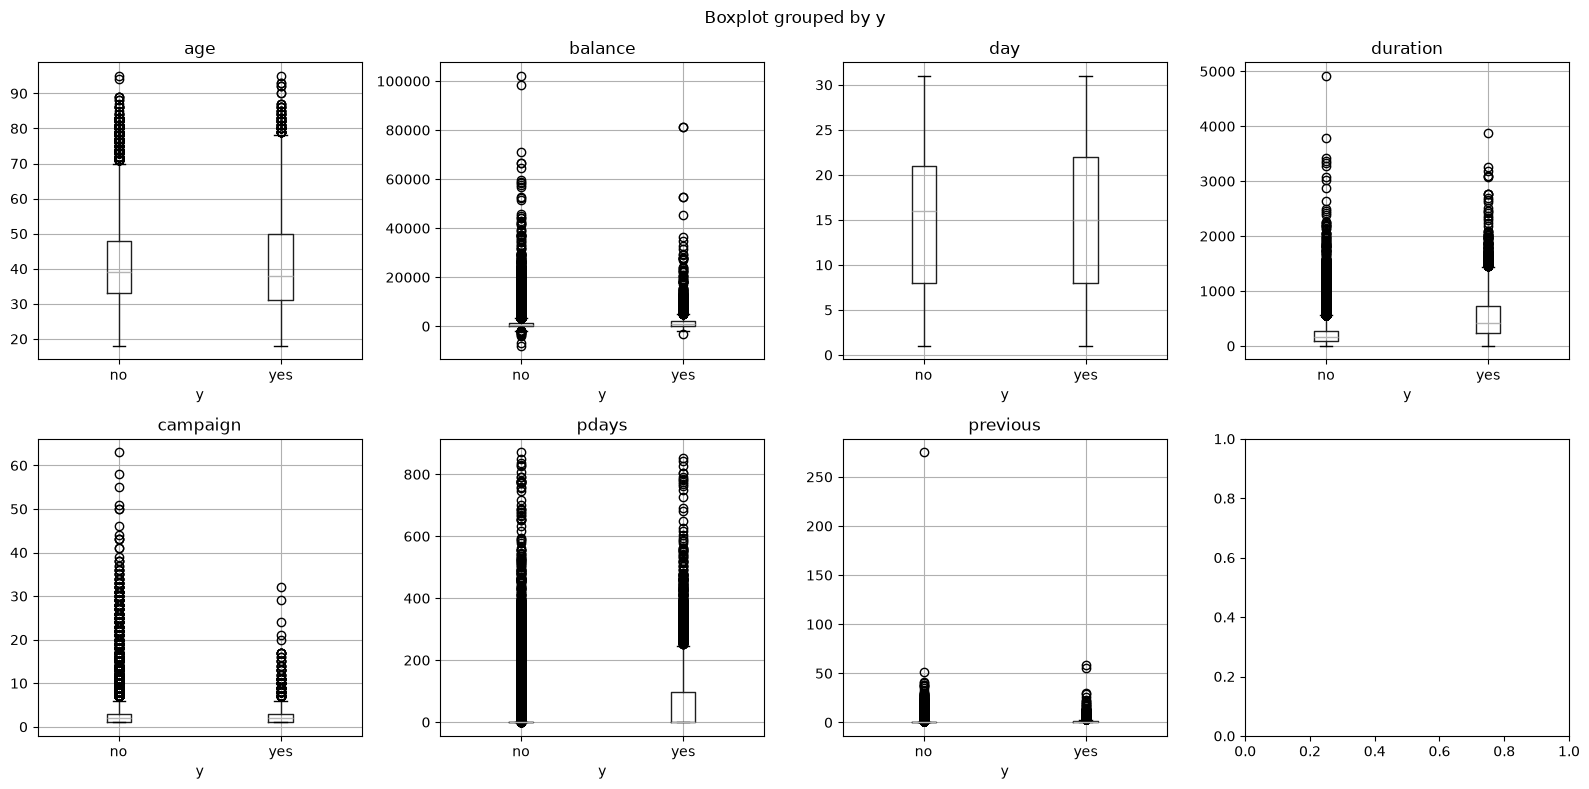

In [15]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    df.boxplot(column=col, by="y", ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

In [16]:
categorical_features = ["job", "marital", "education", "default", "housing", "loan", "contact", "poutcome"]

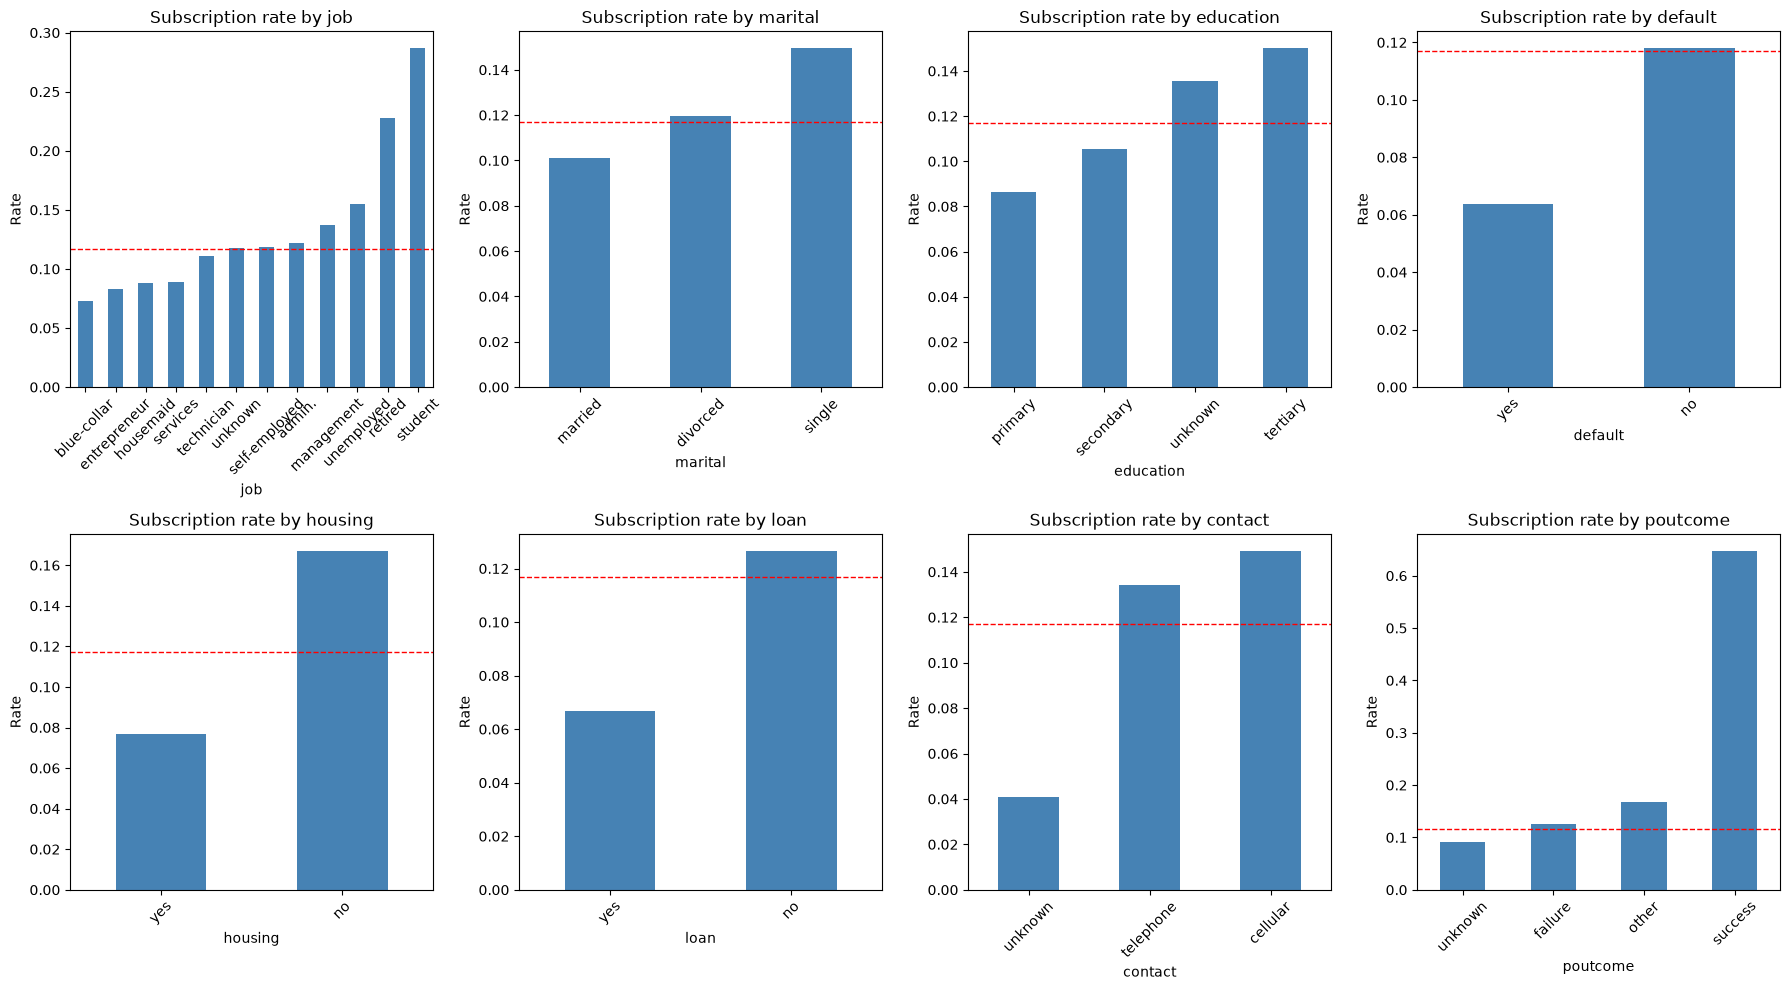

In [17]:
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(categorical_features):
    rate = df.groupby(col)["y"].apply(lambda x: (x == "yes").mean())
    rate.sort_values().plot(kind="bar", ax=axes[i], color="steelblue")
    axes[i].set_title(f"Subscription rate by {col}")
    axes[i].set_ylabel("Rate")
    axes[i].axhline(0.117, color="red", linestyle="--", linewidth=1)
    axes[i].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

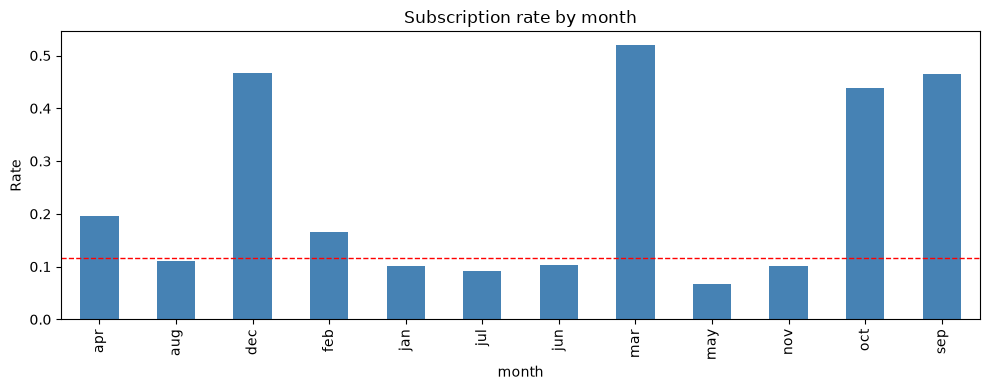

In [18]:
rate_month = df.groupby("month")["y"].apply(lambda x: (x == "yes").mean())
rate_month.plot(kind="bar", color="steelblue", figsize=(10, 4))
plt.axhline(0.117, color="red", linestyle="--", linewidth=1)
plt.title("Subscription rate by month")
plt.ylabel("Rate")
plt.tight_layout()
plt.show()

In [19]:
df["was_contacted_before"] = (df["pdays"] != -1).astype(int)
df["was_contacted_before"].value_counts()

was_contacted_before
0    36954
1     8257
Name: count, dtype: int64

In [20]:
df["pdays"] = df["pdays"].replace(-1, 0)
df["pdays"].describe()

count    45211.000000
mean        41.015195
std         99.792615
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        871.000000
Name: pdays, dtype: float64

In [21]:
df_model = df.drop(columns=["duration"])
df_model.shape

(45211, 17)

In [22]:
cat_cols = ["job", "marital", "education", "default", "housing", 
            "loan", "contact", "month", "poutcome"]

In [23]:
df_encoded = pd.get_dummies(df_model, columns=cat_cols, drop_first=True)
df_encoded.shape

(45211, 43)

In [24]:
df_encoded.columns.tolist()

['age',
 'balance',
 'day',
 'campaign',
 'pdays',
 'previous',
 'y',
 'was_contacted_before',
 'job_blue-collar',
 'job_entrepreneur',
 'job_housemaid',
 'job_management',
 'job_retired',
 'job_self-employed',
 'job_services',
 'job_student',
 'job_technician',
 'job_unemployed',
 'job_unknown',
 'marital_married',
 'marital_single',
 'education_secondary',
 'education_tertiary',
 'education_unknown',
 'default_yes',
 'housing_yes',
 'loan_yes',
 'contact_telephone',
 'contact_unknown',
 'month_aug',
 'month_dec',
 'month_feb',
 'month_jan',
 'month_jul',
 'month_jun',
 'month_mar',
 'month_may',
 'month_nov',
 'month_oct',
 'month_sep',
 'poutcome_other',
 'poutcome_success',
 'poutcome_unknown']

In [25]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   age                   45211 non-null  int64
 1   job                   45211 non-null  str  
 2   marital               45211 non-null  str  
 3   education             45211 non-null  str  
 4   default               45211 non-null  str  
 5   balance               45211 non-null  int64
 6   housing               45211 non-null  str  
 7   loan                  45211 non-null  str  
 8   contact               45211 non-null  str  
 9   day                   45211 non-null  int64
 10  month                 45211 non-null  str  
 11  duration              45211 non-null  int64
 12  campaign              45211 non-null  int64
 13  pdays                 45211 non-null  int64
 14  previous              45211 non-null  int64
 15  poutcome              45211 non-null  str  
 16  y              

In [26]:
df_encoded.info()

<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 43 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   age                   45211 non-null  int64
 1   balance               45211 non-null  int64
 2   day                   45211 non-null  int64
 3   campaign              45211 non-null  int64
 4   pdays                 45211 non-null  int64
 5   previous              45211 non-null  int64
 6   y                     45211 non-null  str  
 7   was_contacted_before  45211 non-null  int64
 8   job_blue-collar       45211 non-null  bool 
 9   job_entrepreneur      45211 non-null  bool 
 10  job_housemaid         45211 non-null  bool 
 11  job_management        45211 non-null  bool 
 12  job_retired           45211 non-null  bool 
 13  job_self-employed     45211 non-null  bool 
 14  job_services          45211 non-null  bool 
 15  job_student           45211 non-null  bool 
 16  job_technician 

In [27]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop(columns=["y"])
y = (df_encoded["y"] == "yes").astype(int)

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)

(36168, 42) (9043, 42)


In [29]:
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

y
0    0.883018
1    0.116982
Name: proportion, dtype: float64
y
0    0.883003
1    0.116997
Name: proportion, dtype: float64


In [30]:
from sklearn.preprocessing import StandardScaler

numeric_cols = ["age", "balance", "day", "campaign", "pdays", "previous"]

In [31]:
scaler = StandardScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

In [32]:
X_train[numeric_cols].describe().round(2)

,age,balance,day,campaign,pdays,previous
count,36168.00,36168.00,36168.00,36168.00,36168.00,36168.00
mean,-0.00,-0.00,0.00,0.00,0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00
min,-2.15,-3.06,-1.78,-0.57,-0.41,-0.24
25%,-0.74,-0.42,-0.94,-0.57,-0.41,-0.24
50%,-0.18,-0.30,0.02,-0.25,-0.41,-0.24
75%,0.67,0.02,0.62,0.08,-0.41,-0.24
max,5.09,32.84,1.82,19.41,8.31,113.93


In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [34]:
y_pred = lr.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.99      0.94      7985
           1       0.66      0.18      0.28      1058

    accuracy                           0.89      9043
   macro avg       0.78      0.58      0.61      9043
weighted avg       0.87      0.89      0.86      9043



In [35]:
from sklearn.model_selection import KFold, StratifiedKFold, cross_val_score

lr_cv = LogisticRegression(max_iter=1000, random_state=42)

In [36]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
kf_scores = cross_val_score(lr_cv, X_train, y_train, cv=kf, scoring="f1")
print("K-Fold F1 scores:", kf_scores.round(3))
print("Mean:", kf_scores.mean().round(3))
print("Std:", kf_scores.std().round(3))

K-Fold F1 scores: [0.28  0.289 0.243 0.268 0.293]
Mean: 0.274
Std: 0.018


In [37]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
skf_scores = cross_val_score(lr_cv, X_train, y_train, cv=skf, scoring="f1")
print("Stratified K-Fold F1 scores:", skf_scores.round(3))
print("Mean:", skf_scores.mean().round(3))
print("Std:", skf_scores.std().round(3))

Stratified K-Fold F1 scores: [0.263 0.295 0.261 0.275 0.275]
Mean: 0.274
Std: 0.012


In [40]:
lr_l2 = LogisticRegression(l1_ratio=0, C=1.0, max_iter=1000, random_state=42)
l2_scores = cross_val_score(lr_l2, X_train, y_train, cv=skf, scoring="f1")
print("L2 F1 scores:", l2_scores.round(3))
print("Mean:", l2_scores.mean().round(3))
print("Std:", l2_scores.std().round(3))

L2 F1 scores: [0.263 0.295 0.261 0.275 0.275]
Mean: 0.274
Std: 0.012


In [41]:
lr_l1 = LogisticRegression(l1_ratio=1, solver="saga", C=1.0, max_iter=1000, random_state=42)
l1_scores = cross_val_score(lr_l1, X_train, y_train, cv=skf, scoring="f1")
print("L1 F1 scores:", l1_scores.round(3))
print("Mean:", l1_scores.mean().round(3))
print("Std:", l1_scores.std().round(3))

L1 F1 scores: [0.263 0.297 0.261 0.274 0.279]
Mean: 0.275
Std: 0.013


In [42]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
import numpy as np

base_lr = LogisticRegression(l1_ratio=0, max_iter=1000, random_state=42)

In [43]:
param_grid = {"C": [0.001, 0.01, 0.1, 1, 10, 100]}

grid_search = GridSearchCV(
    base_lr,
    param_grid,
    cv=skf,
    scoring="f1",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best C:", grid_search.best_params_)
print("Best F1:", round(grid_search.best_score_, 3))

Best C: {'C': 100}
Best F1: 0.274


In [44]:
param_dist = {"C": np.logspace(-4, 4, 1000)}

random_search = RandomizedSearchCV(
    base_lr,
    param_dist,
    n_iter=50,
    cv=skf,
    scoring="f1",
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print("Best C:", random_search.best_params_)
print("Best F1:", round(random_search.best_score_, 3))

Best C: {'C': np.float64(26.880010215376075)}
Best F1: 0.274


In [45]:
round(grid_search.best_score_, 3)

np.float64(0.274)

In [46]:
print("Grid exact F1:", grid_search.best_score_)
print("Random exact F1:", random_search.best_score_)

Grid exact F1: 0.2743785981386722
Random exact F1: 0.2743804490327178


In [47]:
print("Grid best C:", grid_search.best_params_["C"])
print("Random best C:", random_search.best_params_["C"])

Grid best C: 100
Random best C: 26.880010215376075


In [48]:
from sklearn.model_selection import train_test_split

X_raw = df_model.drop(columns=["y"])
y_raw = (df_model["y"] == "yes").astype(int)

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw,
    y_raw,
    test_size=0.2,
    random_state=42,
    stratify=y_raw
)

print(X_train_raw.shape)
print(X_test_raw.shape)

(36168, 16)
(9043, 16)


In [49]:
numeric_cols = [
    "age",
    "balance",
    "day",
    "campaign",
    "pdays",
    "previous"
]

categorical_cols = [
    "job",
    "marital",
    "education",
    "default",
    "housing",
    "loan",
    "contact",
    "month",
    "poutcome"
]

In [50]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        (
            "cat",
            OneHotEncoder(drop="first", handle_unknown="ignore"),
            categorical_cols
        )
    ],
    remainder="passthrough"
)

In [51]:
("num", StandardScaler(), numeric_cols)

('num',
 StandardScaler(),
 ['age', 'balance', 'day', 'campaign', 'pdays', 'previous'])

In [53]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

lr_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

lr_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.

In [54]:
lr_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.

In [55]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

pipeline_scores = cross_val_score(
    lr_pipeline,
    X_train_raw,
    y_train,
    cv=skf,
    scoring="f1",
    n_jobs=-1
)

print("Pipeline F1 scores:", pipeline_scores.round(3))
print("Mean:", pipeline_scores.mean().round(3))
print("Std:", pipeline_scores.std().round(3))

Pipeline F1 scores: [0.265 0.295 0.26  0.275 0.275]
Mean: 0.274
Std: 0.012


In [56]:
LogisticRegression(
    max_iter=1000,
    random_state=42
)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [57]:
from sklearn.base import clone

lr_l2_pipeline = clone(lr_pipeline)

lr_l2_pipeline.set_params(
    model__l1_ratio=0,
    model__C=1.0
)

l2_pipeline_scores = cross_val_score(
    lr_l2_pipeline,
    X_train_raw,
    y_train,
    cv=skf,
    scoring="f1",
    n_jobs=-1
)

print("L2 Pipeline F1 scores:", l2_pipeline_scores.round(3))
print("Mean:", l2_pipeline_scores.mean().round(3))
print("Std:", l2_pipeline_scores.std().round(3))

L2 Pipeline F1 scores: [0.265 0.295 0.26  0.275 0.275]
Mean: 0.274
Std: 0.012


In [58]:
lr_l1_pipeline = clone(lr_pipeline)

lr_l1_pipeline.set_params(
    model__l1_ratio=1,
    model__solver="saga",
    model__C=1.0
)

l1_pipeline_scores = cross_val_score(
    lr_l1_pipeline,
    X_train_raw,
    y_train,
    cv=skf,
    scoring="f1",
    n_jobs=-1
)

print("L1 Pipeline F1 scores:", l1_pipeline_scores.round(3))
print("Mean:", l1_pipeline_scores.mean().round(3))
print("Std:", l1_pipeline_scores.std().round(3))

L1 Pipeline F1 scores: [0.263 0.296 0.261 0.272 0.274]
Mean: 0.273
Std: 0.013


In [59]:
from sklearn.model_selection import GridSearchCV

grid_param_pipeline = {
    "model__C": [0.001, 0.01, 0.1, 1, 10, 100]
}

grid_pipeline = GridSearchCV(
    lr_pipeline,
    grid_param_pipeline,
    cv=skf,
    scoring="f1",
    n_jobs=-1
)

grid_pipeline.fit(X_train_raw, y_train)

print("Best C:", grid_pipeline.best_params_)
print("Best F1:", grid_pipeline.best_score_)

Best C: {'model__C': 10}
Best F1: 0.27460319761311514


In [60]:
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

random_param_pipeline = {
    "model__C": np.logspace(-4, 4, 1000)
}

random_pipeline = RandomizedSearchCV(
    lr_pipeline,
    random_param_pipeline,
    n_iter=50,
    cv=skf,
    scoring="f1",
    random_state=42,
    n_jobs=-1
)

random_pipeline.fit(X_train_raw, y_train)

print("Best C:", random_pipeline.best_params_)
print("Best F1:", random_pipeline.best_score_)

Best C: {'model__C': np.float64(2.491130026067791)}
Best F1: 0.2748540918938183


In [61]:
comparison = pd.DataFrame({
    "Model": [
        "Baseline Logistic Regression",
        "L2 Logistic Regression",
        "L1 Logistic Regression",
        "GridSearchCV Winner",
        "RandomizedSearchCV Winner"
    ],
    
    "Mean CV F1": [
        pipeline_scores.mean(),
        l2_pipeline_scores.mean(),
        l1_pipeline_scores.mean(),
        grid_pipeline.best_score_,
        random_pipeline.best_score_
    ],
    
    "Std CV F1": [
        pipeline_scores.std(),
        l2_pipeline_scores.std(),
        l1_pipeline_scores.std(),
        grid_pipeline.cv_results_["std_test_score"][grid_pipeline.best_index_],
        random_pipeline.cv_results_["std_test_score"][random_pipeline.best_index_]
    ],
    
    "C": [
        1.0,
        1.0,
        1.0,
        grid_pipeline.best_params_["model__C"],
        random_pipeline.best_params_["model__C"]
    ]
})

comparison = comparison.sort_values(
    by="Mean CV F1",
    ascending=False
).reset_index(drop=True)

comparison

,Model,Mean CV F1,Std CV F1,C
0,RandomizedSearchCV Winner,0.274854,0.012386,2.49113
1,GridSearchCV Winner,0.274603,0.013024,10.00000
2,Baseline Logistic Regression,0.274009,0.011906,1.00000
3,L2 Logistic Regression,0.274009,0.011906,1.00000
4,L1 Logistic Regression,0.273231,0.012691,1.00000


In [62]:
grid_results = pd.DataFrame(grid_pipeline.cv_results_)

grid_results[
    [
        "param_model__C",
        "mean_test_score",
        "std_test_score",
        "rank_test_score"
    ]
].sort_values("rank_test_score")

,param_model__C,mean_test_score,std_test_score,rank_test_score
4,10.000,0.274603,0.013024,1
5,100.000,0.274501,0.012991,2
3,1.000,0.274009,0.011906,3
2,0.100,0.265820,0.009246,4
1,0.010,0.195448,0.015805,5
0,0.001,0.002357,0.000005,6


In [63]:
best_model = random_pipeline.best_estimator_

best_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](16,)","['age','job','marital',...,'previous','poutcome','was_contacted_before']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,16
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all

In [64]:
y_pred_final = best_model.predict(X_test_raw)

y_prob_final = best_model.predict_proba(X_test_raw)[:, 1]

In [65]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

accuracy = accuracy_score(y_test, y_pred_final)
precision = precision_score(y_test, y_pred_final)
recall = recall_score(y_test, y_pred_final)
f1 = f1_score(y_test, y_pred_final)
roc_auc = roc_auc_score(y_test, y_prob_final)

print("Accuracy :", round(accuracy, 3))
print("Precision:", round(precision, 3))
print("Recall   :", round(recall, 3))
print("F1       :", round(f1, 3))
print("ROC-AUC  :", round(roc_auc, 3))

Accuracy : 0.893
Precision: 0.664
Recall   : 0.178
F1       : 0.28
ROC-AUC  : 0.772


In [66]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_final))

              precision    recall  f1-score   support

           0       0.90      0.99      0.94      7985
           1       0.66      0.18      0.28      1058

    accuracy                           0.89      9043
   macro avg       0.78      0.58      0.61      9043
weighted avg       0.87      0.89      0.86      9043



In [67]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_final)

print(cm)

[[7890   95]
 [ 870  188]]


In [68]:
cm_df = pd.DataFrame(
    cm,
    index=["Actual No", "Actual Yes"],
    columns=["Predicted No", "Predicted Yes"]
)

cm_df

,Predicted No,Predicted Yes
Actual No,7890,95
Actual Yes,870,188


In [69]:
feature_names = best_model.named_steps[
    "preprocessor"
].get_feature_names_out()

coefficients = best_model.named_steps[
    "model"
].coef_[0]

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

coef_df.head()

,Feature,Coefficient
0,num__age,0.008530
1,num__balance,0.056538
2,num__day,0.034643
3,num__campaign,-0.255637
4,num__pdays,0.011916


In [70]:
positive_features = coef_df.sort_values(
    "Coefficient",
    ascending=False
).head(10)

positive_features

,Feature,Coefficient
39,cat__poutcome_success,2.278682
33,cat__month_mar,1.027013
37,cat__month_sep,0.634972
36,cat__month_oct,0.596248
28,cat__month_dec,0.575139
10,cat__job_retired,0.409407
13,cat__job_student,0.299554
20,cat__education_tertiary,0.295531
38,cat__poutcome_other,0.284659
32,cat__month_jun,0.159814


In [71]:
negative_features = coef_df.sort_values(
    "Coefficient",
    ascending=True
).head(10)

negative_features

,Feature,Coefficient
26,cat__contact_unknown,-1.325491
30,cat__month_jan,-1.138264
35,cat__month_nov,-0.894300
27,cat__month_aug,-0.851095
31,cat__month_jul,-0.712471
23,cat__housing_yes,-0.515755
34,cat__month_may,-0.504301
41,remainder__was_contacted_before,-0.490020
8,cat__job_housemaid,-0.380227
24,cat__loan_yes,-0.377536


In [72]:
encoder = best_model.named_steps[
    "preprocessor"
].named_transformers_["cat"]

for column, categories in zip(
    categorical_cols,
    encoder.categories_
):
    print(
        column,
        "→ reference category:",
        categories[0]
    )

job → reference category: admin.
marital → reference category: divorced
education → reference category: primary
default → reference category: no
housing → reference category: no
loan → reference category: no
contact → reference category: cellular
month → reference category: apr
poutcome → reference category: failure


In [73]:
import joblib

joblib.dump(
    best_model,
    "bank_marketing_logistic_pipeline.pkl"
)

['bank_marketing_logistic_pipeline.pkl']

In [74]:
loaded_model = joblib.load(
    "bank_marketing_logistic_pipeline.pkl"
)

loaded_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](16,)","['age','job','marital',...,'previous','poutcome','was_contacted_before']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,16
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all

In [75]:
loaded_model = joblib.load(
    "bank_marketing_logistic_pipeline.pkl"
)

loaded_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](16,)","['age','job','marital',...,'previous','poutcome','was_contacted_before']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,16
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all

In [76]:
original_predictions = best_model.predict(X_test_raw)
loaded_predictions = loaded_model.predict(X_test_raw)

print(
    "Predictions identical:",
    np.array_equal(
        original_predictions,
        loaded_predictions
    )
)

Predictions identical: True


In [77]:
sample_customer = X_test_raw.iloc[[0]]

sample_customer

,age,job,marital,education,default,balance,housing,loan,contact,day,month,campaign,pdays,previous,poutcome,was_contacted_before
1392,40,blue-collar,married,primary,no,640,yes,yes,unknown,8,may,2,0,0,unknown,0


In [78]:
sample_prediction = loaded_model.predict(
    sample_customer
)[0]

sample_probability = loaded_model.predict_proba(
    sample_customer
)[0, 1]

print("Prediction:", sample_prediction)
print(
    "Probability of subscription:",
    round(sample_probability, 3)
)

Prediction: 0
Probability of subscription: 0.013
